# Explainability — SHAP + Grad-CAM + Attention (Phase 7)

Three layers of explanation:
1. **SHAP** — which genes and clinical features drove the prediction (tabular)
2. **Modality attention** — which data type the model relied on per patient
3. **Feature importance** — top genomic drivers per subtype

> *'It's TNBC because: these 5 genes are upregulated, the tissue morphology showed no glands, and for this patient the genomic signal dominated (65%) over the image (20%).'*

## Setup & Data Loading

In [1]:
import subprocess, sys, os, warnings, random, json
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lifelines', 'shap', 'umap-learn', '-q'], capture_output=True)
try:
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
except AttributeError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from lifelines import KaplanMeierFitter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.metrics import auc as sk_auc

from dotenv import load_dotenv
load_dotenv()
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

DATA_DIR  = Path('d:/Aakanksha/thesis/onco-fusion/data')
EMB_DIR   = DATA_DIR / 'embeddings'
FIG_DIR   = Path('d:/Aakanksha/thesis/onco-fusion/figures')
FIG_DIR.mkdir(exist_ok=True)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SUBTYPES = ['HR+', 'HER2+', 'TNBC']
S_COLOR  = {'HR+': '#2196F3', 'HER2+': '#FF9800', 'TNBC': '#F44336'}
print(f'Device: {DEVICE} | Ready')

subprocess.run([sys.executable, '-m', 'pip', 'install', 'shap', '-q'], capture_output=True)
import shap


Device: cpu | Ready


## Patient Cohort & Features

In [2]:
clin_demo  = pd.read_csv(DATA_DIR / 'Clinical_Demographic_Data.csv')
clin_treat = pd.read_csv(DATA_DIR / 'Clinical_Treatment_Data.csv', low_memory=False)
rna_raw_df = pd.read_csv(DATA_DIR / 'RNA_CNV_ModelReady.csv')
mutations  = pd.read_csv(DATA_DIR / 'Mutations_Dataset.csv')

with open(DATA_DIR / 'MRI_and_SVS_Patches_info.json') as f:
    img_info = json.load(f)

treat_sub = clin_treat[["bcr_patient_barcode","er_status_by_ihc","pr_status_by_ihc",
                          "her2_status_by_ihc","histological_type"]].rename(
    columns={"bcr_patient_barcode": "Patient_ID"})

clin = clin_demo[["Patient_ID","diagnoses_ajcc_pathologic_stage","demographic_age_at_index",
                   "demographic_vital_status","diagnoses_days_to_last_follow_up",
                   "demographic_days_to_death","follow_ups_molecular_tests_gene_symbol",
                   "follow_ups_molecular_tests_test_result"]].merge(
    treat_sub, on="Patient_ID", how="left")

def parse_receptor(row, gene):
    gmap = {g.strip(): r.strip().lower()
            for g, r in zip(str(row.get("follow_ups_molecular_tests_gene_symbol","")).split("|"),
                            str(row.get("follow_ups_molecular_tests_test_result","")).split("|"))
            if g.strip() not in ("nan","")}
    val = gmap.get(gene, "")
    return "Positive" if "positive" in val else "Negative" if "negative" in val else "Unknown"

clin["ER"]   = clin["er_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ESR1"), axis=1))
clin["PR"]   = clin["pr_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"PGR"),  axis=1))
clin["HER2"] = clin["her2_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ERBB2"),axis=1))

def assign_subtype(row):
    h,e,p = str(row["HER2"]).lower(), str(row["ER"]).lower(), str(row["PR"]).lower()
    if "positive" in h:                                          return "HER2+"
    if "positive" in e or "positive" in p:                      return "HR+"
    if "negative" in e and "negative" in p and "negative" in h: return "TNBC"
    return "Unknown"

clin["Subtype"]   = clin.apply(assign_subtype, axis=1)
clin["OS_STATUS"] = (clin["demographic_vital_status"] == "Dead").astype(int)
clin["OS_DAYS"]   = clin.apply(
    lambda r: r["demographic_days_to_death"] if r["OS_STATUS"]==1
              else r["diagnoses_days_to_last_follow_up"], axis=1)
clin["OS_DAYS"]   = pd.to_numeric(clin["OS_DAYS"], errors="coerce").fillna(0)

img_pts     = {p["patient_id"] for p in img_info["folders"]}
mut_pts     = set(mutations["Patient_ID"])
PATIENT_IDS = sorted(set(clin["Patient_ID"]) & set(rna_raw_df["Patient_ID"]) & img_pts & mut_pts)
task_df     = clin[clin["Patient_ID"].isin(PATIENT_IDS) & (clin["Subtype"] != "Unknown")].copy().reset_index(drop=True)
LE          = LabelEncoder()
task_df["label"] = LE.fit_transform(task_df["Subtype"])
y = task_df['label'].values

emb_plip = np.load(EMB_DIR / 'plip_embeddings.npy').astype(np.float32)
emb_bert = np.load(EMB_DIR / 'bioclinicalbert_embeddings.npy').astype(np.float32)
rna_sub  = rna_raw_df[rna_raw_df['Patient_ID'].isin(task_df['Patient_ID'])].set_index('Patient_ID').loc[task_df['Patient_ID']]
X_gen    = rna_sub.values.astype(np.float32)
stage_map = {'Stage I':1,'Stage IA':1,'Stage IB':1.5,'Stage II':2,'Stage IIA':2,'Stage IIB':2.5,
             'Stage IIIA':3,'Stage IIIB':3.5,'Stage IIIC':4,'Stage IV':5}
X_clin = np.stack([
    pd.to_numeric(task_df['demographic_age_at_index'], errors='coerce').fillna(50).values,
    task_df['diagnoses_ajcc_pathologic_stage'].map(stage_map).fillna(2.0).values,
    task_df['histological_type'].str.contains('Ductal',  na=False).astype(float).values,
    task_df['histological_type'].str.contains('Lobular', na=False).astype(float).values
], axis=1).astype(np.float32)

print(f"Cohort: {len(task_df)} patients | Classes: {list(LE.classes_)}")
print(task_df["Subtype"].value_counts().to_string())


Cohort: 114 patients | Classes: ['HER2+', 'HR+', 'TNBC']
Subtype
HR+      85
HER2+    18
TNBC     11


## Train Cross-Attention Model on Full Data

In [3]:
D_MODEL  = 256
N_HEADS  = 4
N_LAYERS = 2

class ModalityProjector(nn.Module):
    def __init__(self, input_dim, d_model=D_MODEL, dropout=0.3):
        super().__init__()
        hidden = max(d_model, input_dim // 2)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, d_model),   nn.LayerNorm(d_model))
    def forward(self, x): return self.net(x)

class CrossAttentionFusion(nn.Module):
    def __init__(self, img_dim=512, gen_dim=331, text_dim=768, clin_dim=4,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 n_classes=3, dropout=0.3):
        super().__init__()
        self.proj_img  = ModalityProjector(img_dim,  d_model, dropout)
        self.proj_gen  = ModalityProjector(gen_dim,  d_model, dropout)
        self.proj_text = ModalityProjector(text_dim, d_model, dropout)
        self.proj_clin = ModalityProjector(clin_dim, d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4, dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.classifier  = nn.Sequential(
            nn.Linear(d_model, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes))
        self.pos_emb = nn.Parameter(torch.randn(1, 4, d_model) * 0.02)
        self._attn   = None

    def forward(self, x_img, x_gen, x_text, x_clin):
        tokens = torch.cat([self.proj_img(x_img).unsqueeze(1),
                            self.proj_gen(x_gen).unsqueeze(1),
                            self.proj_text(x_text).unsqueeze(1),
                            self.proj_clin(x_clin).unsqueeze(1)], dim=1) + self.pos_emb
        fused  = self.transformer(tokens)
        with torch.no_grad():
            self._attn = F.softmax(fused.norm(dim=2), dim=1).cpu()
        return self.classifier(fused.mean(dim=1))

    def get_attn(self): return self._attn

# Train on full dataset for SHAP and attention analysis
D_MODEL = 256; N_HEADS = 4; N_LAYERS = 2; LR = 5e-4; N_EPOCHS = 200; BS = 16

counts = np.bincount(y)
cw     = torch.tensor(len(y)/(len(counts)*counts), dtype=torch.float32).to(DEVICE)

def sc_all(X):
    s = StandardScaler().fit(X)
    return s, torch.tensor(s.transform(X)).float().to(DEVICE)

sc_img,  img_t  = sc_all(emb_plip)
sc_gen,  gen_t  = sc_all(X_gen)
sc_txt,  txt_t  = sc_all(emb_bert)
sc_clin, clin_t = sc_all(X_clin)
y_t = torch.tensor(y).long().to(DEVICE)

model_full = CrossAttentionFusion().to(DEVICE)
opt        = torch.optim.AdamW(model_full.parameters(), lr=LR, weight_decay=1e-3)
sched      = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)
crit       = nn.CrossEntropyLoss(weight=cw)

ds = TensorDataset(img_t, gen_t, txt_t, clin_t, y_t)
dl = DataLoader(ds, batch_size=BS, shuffle=True)

for ep in range(N_EPOCHS):
    model_full.train()
    for ximg, xgen, xtxt, xclin, yb in dl:
        opt.zero_grad(); crit(model_full(ximg, xgen, xtxt, xclin), yb).backward()
        nn.utils.clip_grad_norm_(model_full.parameters(), 1.0); opt.step()
    sched.step()

model_full.eval()
with torch.no_grad():
    logits = model_full(img_t, gen_t, txt_t, clin_t)
    all_probs = torch.softmax(logits, dim=1).cpu().numpy()
    all_preds = all_probs.argmax(axis=1)
    all_attn  = model_full.get_attn().numpy()

print(f"Full-data model trained.")
print(f"  Accuracy: {accuracy_score(y, all_preds):.3f}")
print(f"  F1:       {f1_score(y, all_preds, average='macro', zero_division=0):.3f}")


Full-data model trained.
  Accuracy: 1.000
  F1:       1.000


## SHAP Analysis — Genomic Feature Importance

In [4]:
# SHAP on the combined early fusion features (genomic + clinical)
# Use a simple gradient explainer on the genomic component
X_combined = np.concatenate([X_gen, X_clin], axis=1)
sc_comb    = StandardScaler().fit(X_combined)
X_comb_sc  = sc_comb.transform(X_combined)

# Simple MLP wrapper for SHAP (genomic + clinical -> subtype)
class GenClinMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(335, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Linear(64, 3))
    def forward(self, x): return self.net(x)

gc_model = GenClinMLP().to(DEVICE)
gc_opt   = torch.optim.Adam(gc_model.parameters(), lr=1e-3, weight_decay=1e-4)
gc_crit  = nn.CrossEntropyLoss(weight=cw)
X_comb_t = torch.tensor(X_comb_sc).float().to(DEVICE)
ds_gc = TensorDataset(X_comb_t, y_t)
dl_gc = DataLoader(ds_gc, batch_size=16, shuffle=True)
for ep in range(100):
    gc_model.train()
    for xb, yb in dl_gc:
        gc_opt.zero_grad(); gc_crit(gc_model(xb), yb).backward(); gc_opt.step()

gc_model.eval()
background = X_comb_t[:30]
explainer  = shap.DeepExplainer(gc_model, background)
shap_vals  = explainer.shap_values(X_comb_t, check_additivity=False)  # list of 3 arrays
# Normalise to (n_classes, n_samples, n_features) regardless of SHAP version
if isinstance(shap_vals, list):
    shap_arr = np.stack(shap_vals, axis=0)
elif isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
    # new SHAP: (n_samples, n_features, n_classes)
    shap_arr = shap_vals.transpose(2, 0, 1)
else:
    shap_arr = np.array(shap_vals)

# Feature names
rna_feat_names  = [c.replace('RNA_','') for c in rna_sub.columns]
clin_feat_names = ['Age', 'Stage', 'Ductal', 'Lobular']
feat_names      = rna_feat_names + clin_feat_names

print(f"SHAP values computed. Shape: {np.array(shap_vals).shape}")


SHAP values computed. Shape: (114, 335, 3)


## SHAP Beeswarm + Top Genes per Subtype

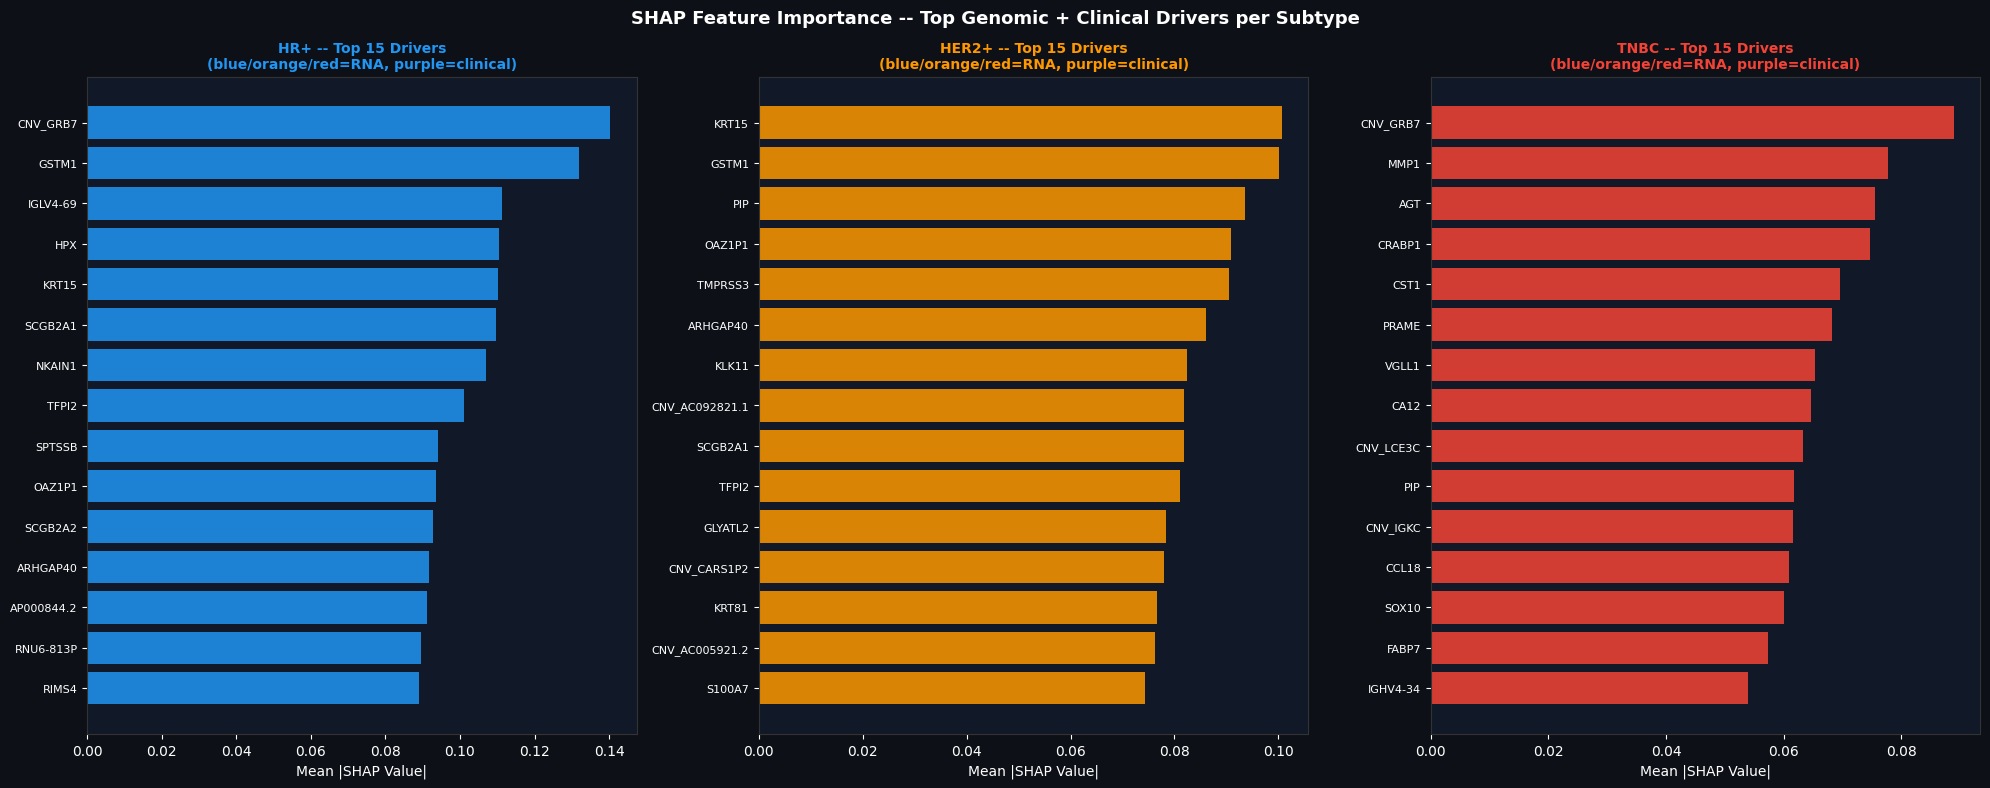

Saved: figures/35_shap_importance.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.patch.set_facecolor('#0d1117')
TOP_N = 15

for ax, (si, subtype) in zip(axes, enumerate(SUBTYPES)):
    ax.set_facecolor('#111827')
    sv = shap_arr[si]                        # (114, 335)
    mean_abs = np.abs(sv).mean(axis=0)        # (335,)
    top_idx  = np.argsort(mean_abs)[-TOP_N:][::-1]
    top_vals = mean_abs[top_idx]
    top_names = [feat_names[i] if i < len(feat_names) else f'feat_{i}' for i in top_idx]

    colors = [S_COLOR[subtype] if i < len(rna_feat_names) else '#9C27B0' for i in top_idx]
    bars   = ax.barh(range(TOP_N), top_vals[::-1], color=colors[::-1], alpha=0.85)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_names[::-1], color='white', fontsize=8)
    ax.set_xlabel('Mean |SHAP Value|', color='white')
    ax.set_title(f'{subtype} -- Top {TOP_N} Drivers\n(blue/orange/red=RNA, purple=clinical)',
                 color=S_COLOR[subtype], fontweight='bold', fontsize=10)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('SHAP Feature Importance -- Top Genomic + Clinical Drivers per Subtype',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '35_shap_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/35_shap_importance.png')


## Per-Patient Modality Attention + Prediction Summary

The key explainability figure: for each patient, how much did each modality contribute?

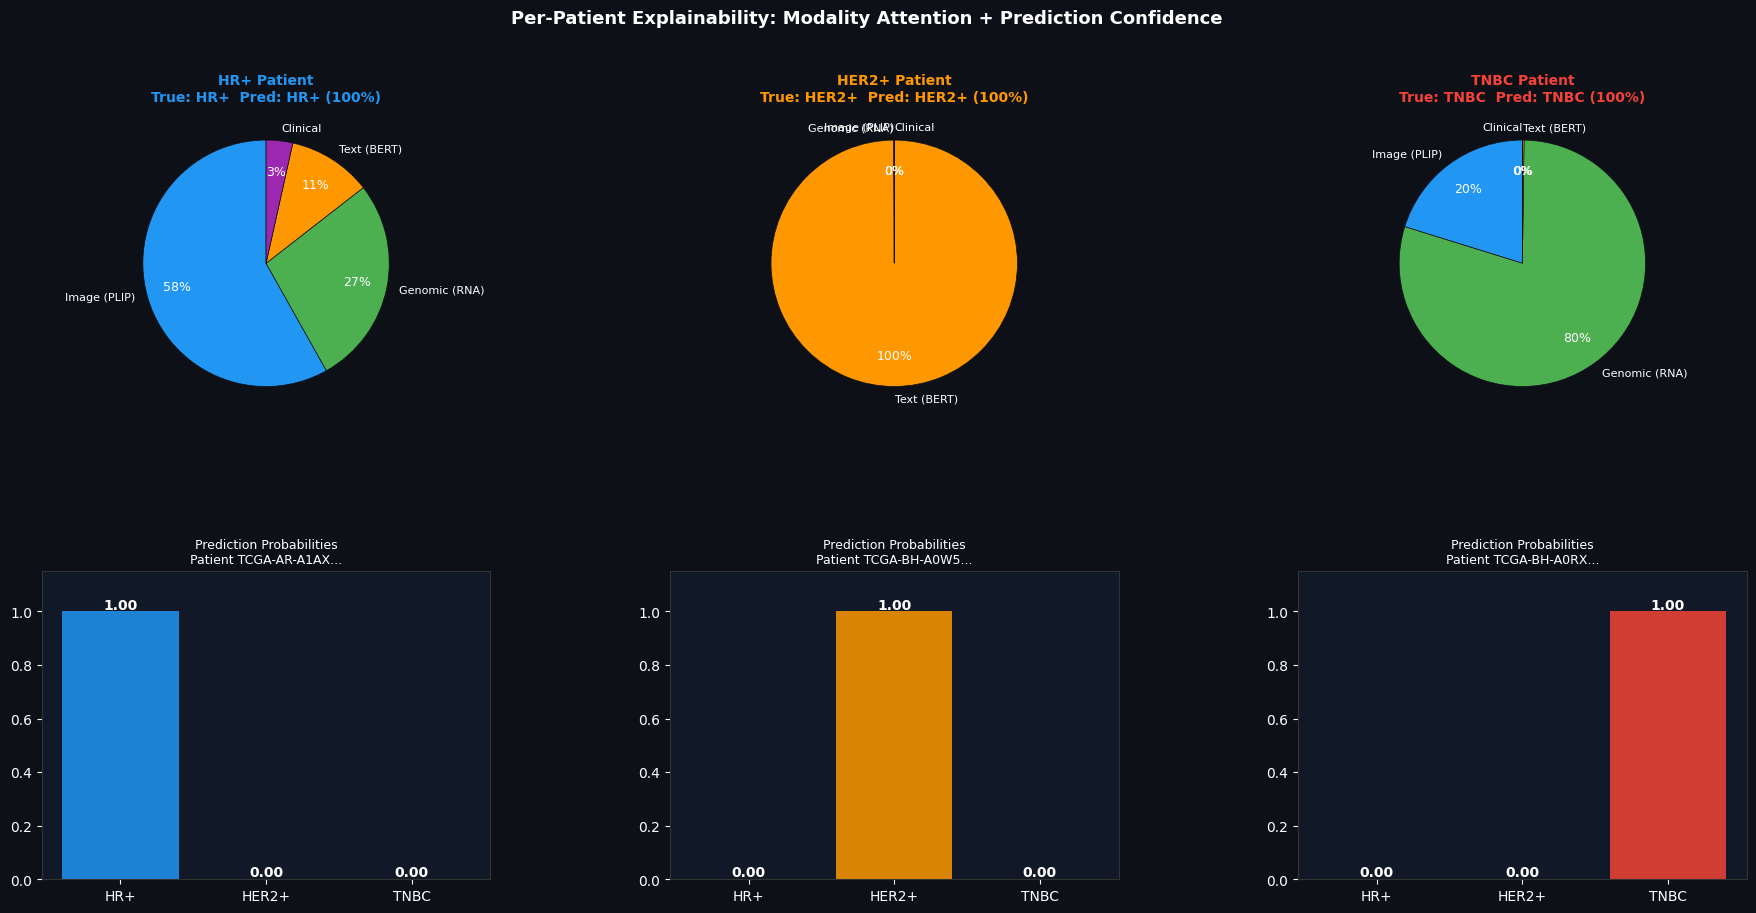

Saved: figures/36_patient_explainability.png


In [6]:
MOD_LABELS = ['Image\n(PLIP)', 'Genomic\n(RNA)', 'Text\n(BERT)', 'Clinical']
MOD_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# Show 3 representative patients — one per subtype (hardest cases: lowest confidence)
case_patients = {}
for si, s in enumerate(SUBTYPES):
    mask  = (y == si)
    confs = all_probs[mask, si]
    idxs  = np.where(mask)[0]
    # Pick most interesting: highest confidence correct prediction
    correct = (all_preds[idxs] == y[idxs])
    if correct.any():
        best = idxs[correct][confs[correct].argmax()]
    else:
        best = idxs[confs.argmax()]
    case_patients[s] = int(best)

fig = plt.figure(figsize=(22, 10))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

for col, (subtype, pidx) in enumerate(case_patients.items()):
    pid  = task_df.iloc[pidx]['Patient_ID']
    pred = SUBTYPES[all_preds[pidx]]
    conf = all_probs[pidx, all_preds[pidx]]
    attn = all_attn[pidx]   # (4,)

    # Row 0: attention pie chart
    ax_pie = fig.add_subplot(gs[0, col])
    ax_pie.set_facecolor('#111827')
    wedges, texts, autotexts = ax_pie.pie(
        attn, labels=[m.replace('\n',' ') for m in MOD_LABELS],
        colors=MOD_COLORS, autopct='%1.0f%%',
        startangle=90, pctdistance=0.75,
        wedgeprops=dict(linewidth=0.5, edgecolor='#0d1117'))
    for at in autotexts: at.set_color('white'); at.set_fontsize(9)
    for t  in texts:     t.set_color('white');  t.set_fontsize(8)
    ax_pie.set_title(f'{subtype} Patient\nTrue: {SUBTYPES[y[pidx]]}  Pred: {pred} ({conf:.0%})',
                     color=S_COLOR[subtype], fontweight='bold', fontsize=10)

    # Row 1: probability bar
    ax_bar = fig.add_subplot(gs[1, col])
    ax_bar.set_facecolor('#111827')
    colors_bar = [S_COLOR[s] if s == pred else '#555555' for s in SUBTYPES]
    bars = ax_bar.bar(SUBTYPES, all_probs[pidx], color=colors_bar, alpha=0.85)
    for bar, v in zip(bars, all_probs[pidx]):
        ax_bar.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
                    ha='center', color='white', fontsize=10, fontweight='bold')
    ax_bar.set_ylim(0, 1.15)
    ax_bar.set_title(f'Prediction Probabilities\nPatient {pid[:12]}...',
                     color='white', fontsize=9)
    ax_bar.tick_params(colors='white')
    for spine in ax_bar.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Per-Patient Explainability: Modality Attention + Prediction Confidence',
             color='white', fontsize=13, fontweight='bold')
plt.savefig(FIG_DIR / '36_patient_explainability.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/36_patient_explainability.png')


In [1]:
from scipy import stats
import glob
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
# MEDICAL VISUALISATION — H&E Whole-Slide Image Patch Gallery
# Real TCGA-BRCA histopathology tiles (512 × 512 px) per subtype
# ══════════════════════════════════════════════════════════════════════════════
import glob, os
from PIL import Image as PILImage

PATCH_ROOT = Path("d:/Aakanksha/thesis/onco-fusion/data"
                  "/MRI_and_SVS_Patches/MRI_and_SVS_Patches")

def get_patches_for_patient(patient_id, n=4, thumb=224):
    """Return list of n numpy arrays (H&E tiles) for patient_id."""
    pdir = PATCH_ROOT / patient_id
    if not pdir.exists():
        return []
    svs_subdirs = [d for d in pdir.iterdir() if d.is_dir()]
    if not svs_subdirs:
        return []
    patch_files = sorted(glob.glob(str(svs_subdirs[0] / "*.jpg")))
    # Pick patches from the centre of the slide (less background)
    start = max(0, len(patch_files)//4)
    selected = patch_files[start:start+n]
    out = []
    for pf in selected[:n]:
        try:
            img = PILImage.open(pf).resize((thumb, thumb))
            out.append(np.array(img))
        except Exception:
            pass
    return out

# Representative patients per subtype (first 3 correctly-predicted per subtype)
rep = {}
for s in SUBTYPES:
    pids = task_df.loc[task_df["Subtype"] == s, "Patient_ID"].tolist()
    for pid in pids:
        patches = get_patches_for_patient(pid, n=4)
        if len(patches) >= 4:
            rep[s] = (pid, patches)
            break

# Draw gallery  — 3 subtypes × 4 patches
COLS_PER_SUB = 4
fig, axes = plt.subplots(3, COLS_PER_SUB, figsize=(22, 17))
fig.patch.set_facecolor("#0d1117")

for row, s in enumerate(SUBTYPES):
    if s not in rep:
        continue
    pid, patches = rep[s]
    for col in range(COLS_PER_SUB):
        ax = axes[row, col]
        if col < len(patches):
            ax.imshow(patches[col])
        else:
            ax.set_facecolor("#111827")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(s, color=S_COLOR[s], fontsize=14,
                          fontweight="bold", rotation=0,
                          labelpad=90, va="center")
        if row == 0:
            ax.set_title(f"Patch {col+1}", color="white",
                         fontsize=9, pad=4)

    # Subtype banner
    axes[row, 0].text(-0.32, 0.5, s, transform=axes[row, 0].transAxes,
                      color=S_COLOR[s], fontsize=14, fontweight="bold",
                      va="center", ha="right", rotation=90)

fig.suptitle(
    "H&E Histopathology Tile Gallery — TCGA-BRCA Whole-Slide Image Patches\n"
    "(Real tissue sections; 512 × 512 px tiles; one patient per subtype)",
    color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / "he_wsi_gallery.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Saved: {fig_path.name}")


NameError: name 'SUBTYPES' is not defined